In [2]:
import pandas as pd

df = pd.read_csv("amazon_sales_dataset.csv")

In [3]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [4]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [5]:
from sklearn.model_selection import train_test_split

X = df[["price","discount_percent","quantity_sold","rating","review_count"]]
y = df["total_revenue"]

In [9]:
df = df.fillna(0)

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(x_train, y_train)

RandomForestRegressor()

In [13]:
pred = model.predict(x_test)

In [14]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, pred)
print(r2)

0.9999975336991119


In [22]:
result = pd.DataFrame({"Real": y_test, "Predicted": pred})

result.head(10)

,Real,Predicted
745,206.92,206.8566
43243,1903.92,1904.3084
49928,1014.93,1015.6134
22232,30.92,30.7007
9832,166.14,166.7766
37479,212.57,212.5346
38466,188.70,188.5206
35220,288.90,288.9662
23707,985.74,985.1733
20014,254.55,254.6002


In [24]:
importance = pd.Series(model.feature_importances_,index=X.columns)

importance.sort_values(ascending=False)

,0
price,0.523821
quantity_sold,0.445084
discount_percent,0.031090
review_count,0.000002
rating,0.000002


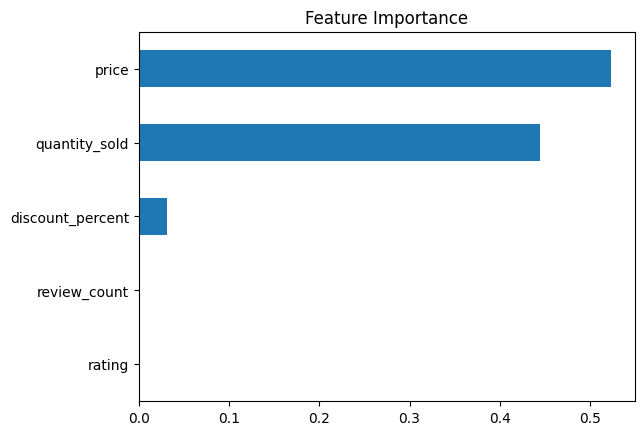

In [26]:
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

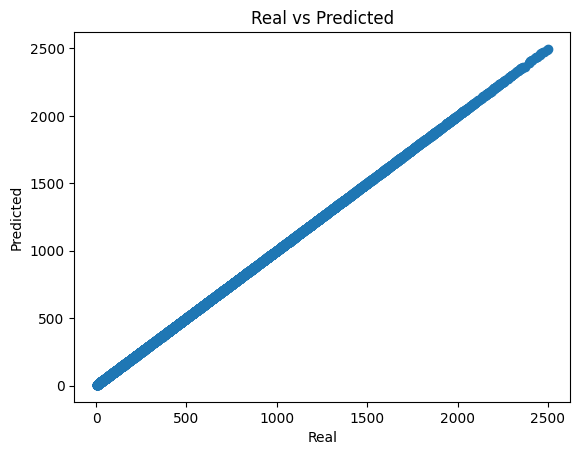

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Real vs Predicted")
plt.show()

In [27]:
from  sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)

result["error"] = result["Real"] - result["Predicted"]

result.sort_values("error", ascending=False).head(10)


,Real,Predicted,error
29021,220.40,213.9575,6.4425
44244,400.25,394.1170,6.1330
36385,2370.85,2365.5795,5.2705
17061,866.97,861.8211,5.1489
30457,127.22,122.1298,5.0902
14145,266.30,261.2190,5.0810
22909,262.55,257.8205,4.7295
31519,596.70,591.9725,4.7275
48780,194.88,190.1649,4.7151
38595,750.40,745.8330,4.5670
